# Computer Vision — Session 1 Lab: Images & CNNs
### ITI · Instructor: Ahmed Abdelsalam

Hands-on time. You'll manipulate images, apply filters and *see* what they do, then build and train a small CNN on handwritten digits.

**Rules of the lab**
- Made for **Google Colab** — run cells top to bottom.
- Try first, ask second. Look at the pictures — CV is visual.
- Done early? Head to the **Challenges**.

## Setup — run this first

In [15]:
# !pip install opencv-python scikit-image torch torchvision matplotlib
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import data
img = data.astronaut()
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
print("Ready. img:", img.shape, "gray:", gray.shape)

Ready. img: (512, 512, 3) gray: (512, 512)


## Exercise 1 — Explore an image as an array

1. Print the **shape** and **dtype** of `img`.
2. Print the **min** and **max** pixel values.
3. Show the image, and separately show its **green channel** in grayscale.

Shape: (512, 512, 3)
Data Type: uint8
Min Pixel: 0
Max Pixel: 255


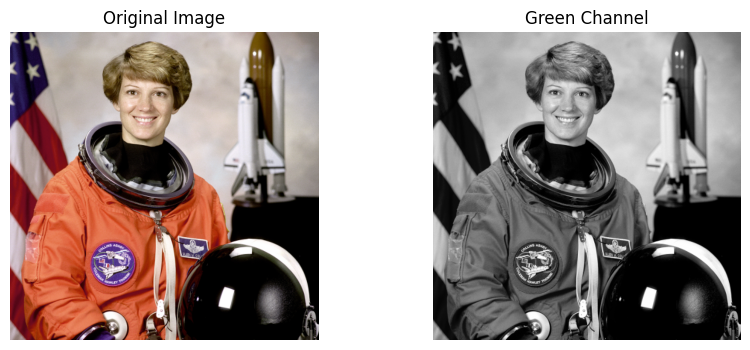

In [16]:
# Your code here

print("Shape:", img.shape)
print("Data Type:", img.dtype)
print("Min Pixel:", img.min())
print("Max Pixel:", img.max())
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(img[:,:,1], cmap="gray")
plt.title("Green Channel")
plt.axis("off")

plt.show()

## Exercise 2 — Resize, crop, flip

1. Resize `img` to **100×100** and show it.
2. Crop the **center** of the image (roughly the middle 200×200 region) using slicing, and show it.
3. Flip the image **vertically** (`cv2.flip(img, 0)`) and show it.

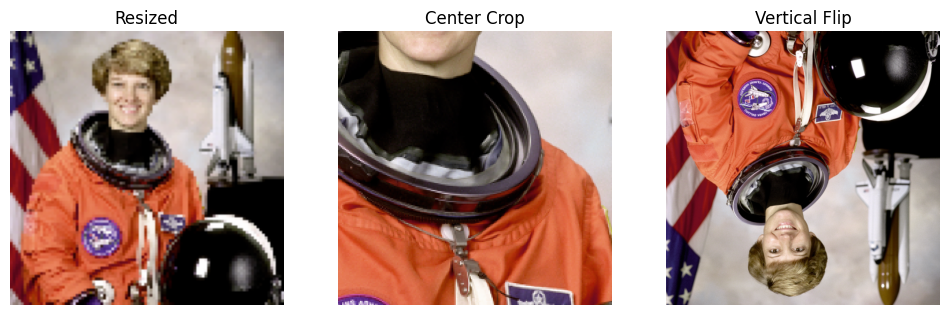

In [17]:
# Your code here
resized = cv2.resize(img, (100,100))
h, w = img.shape[:2]
cropped = img[h//2-100:h//2+100, w//2-100:w//2+100]
flipped = cv2.flip(img, 0)
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(resized)
plt.title("Resized")
plt.axis("off")
plt.subplot(1,3,2)
plt.imshow(cropped)
plt.title("Center Crop")
plt.axis("off")
plt.subplot(1,3,3)
plt.imshow(flipped)
plt.title("Vertical Flip")
plt.axis("off")

plt.show()

## Exercise 3 — Apply filters by hand

Use `cv2.filter2D(image, -1, kernel)` to apply each of these to the **grayscale** image and show the result next to the original:

1. A **blur** kernel: a 5×5 grid of ones divided by 25.
2. A **sharpen** kernel: `[[0,-1,0],[-1,5,-1],[0,-1,0]]`.
3. A **vertical-edge** kernel (Sobel): `[[-1,0,1],[-2,0,2],[-1,0,1]]`.

Look closely — what does each one emphasise?

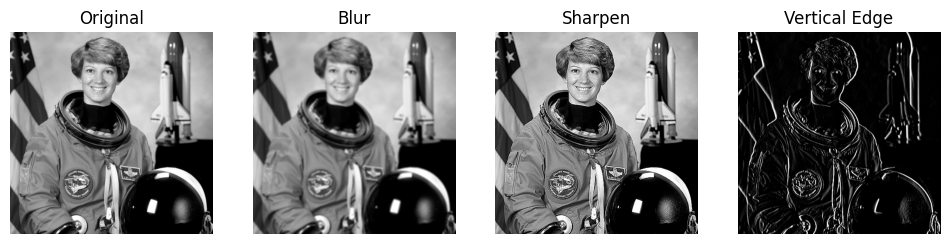

In [18]:
# Your code here
blur = np.ones((5,5), np.float32) / 25
sharpen = np.array([  [0,-1,0],  [-1,5,-1],  [0,-1,0]])
sobel = np.array([ [-1,0,1], [-2,0,2], [-1,0,1]])
blur_img = cv2.filter2D(gray,-1,blur)
sharp_img = cv2.filter2D(gray,-1,sharpen)
edge_img = cv2.filter2D(gray,-1,sobel)

plt.figure(figsize=(12,4))
plt.subplot(1,4,1)
plt.imshow(gray,cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(blur_img,cmap="gray")
plt.title("Blur")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(sharp_img,cmap="gray")
plt.title("Sharpen")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(edge_img,cmap="gray")
plt.title("Vertical Edge")
plt.axis("off")

plt.show()

## Exercise 4 — Build & train a small CNN on digits (MNIST)

This is the main event. We'll train a CNN to recognise handwritten digits.

**Step 1 — load the data** (run as given):

train: 6000 test: 1000


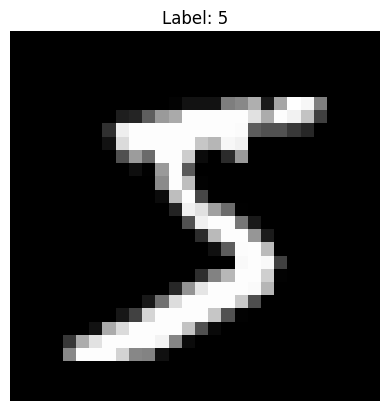

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

transform = transforms.ToTensor()
train_data = datasets.MNIST("./data", train=True,  download=True, transform=transform)
test_data  = datasets.MNIST("./data", train=False, download=True, transform=transform)

train_small = Subset(train_data, range(6000))
test_small  = Subset(test_data,  range(1000))
train_loader = DataLoader(train_small, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_small,  batch_size=64)
print("train:", len(train_small), "test:", len(test_small))
image, label = train_data[0]
plt.imshow(image.squeeze(), cmap="gray"); plt.title(f"Label: {label}"); plt.axis("off"); plt.show()

**Step 2 — define the CNN.** Fill in the `forward` method: conv1 → relu → pool, then conv2 → relu → pool, then flatten, then fc1 → relu, then fc2.

In [20]:
# Your code here

class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1,8,3,padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(8,16,3,padding=1)
        self.fc1 = nn.Linear(16*7*7,64)
        self.fc2 = nn.Linear(64,10)
    def forward(self,x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x,1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x
model = CNN()

**Step 3 — train for 2 epochs** and print the loss. (Fill in the training loop: zero grads, forward, loss, backward, step.)

In [21]:
# Your code here
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
for epoch in range(2):
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, Loss = {loss.item():.4f}")

Epoch 1, Loss = 0.6393
Epoch 2, Loss = 0.4526


**Step 4 — check accuracy** on the test set.

In [22]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        predicted = outputs.argmax(dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

print(f"Test accuracy: {100 * correct / total:.1f}%")

Test accuracy: 84.8%


## Exercise 5 — See what the network "sees" (feature maps)

Pass one digit through `conv1` and display a few of its **feature maps** — the outputs of the learned filters. (Run as given, then read the note below.)

feature maps shape: torch.Size([1, 8, 28, 28])


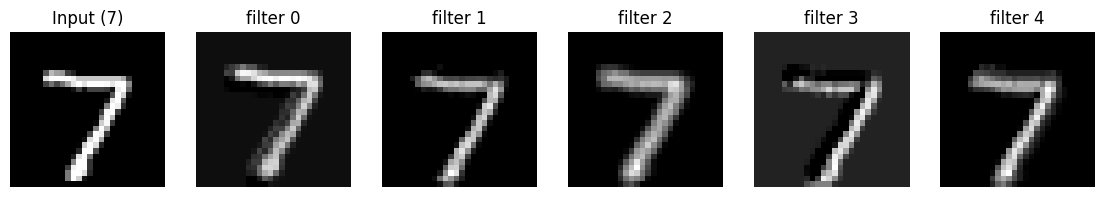

In [23]:
sample_img, sample_label = test_data[0]
batch = sample_img.unsqueeze(0)
model.eval()
with torch.no_grad():
    feature_maps = F.relu(model.conv1(batch))
print("feature maps shape:", feature_maps.shape)

fig, ax = plt.subplots(1, 6, figsize=(14, 3))
ax[0].imshow(sample_img.squeeze(), cmap="gray"); ax[0].set_title(f"Input ({sample_label})"); ax[0].axis("off")
for i in range(5):
    ax[i+1].imshow(feature_maps[0, i], cmap="gray")
    ax[i+1].set_title(f"filter {i}")
    ax[i+1].axis("off")
plt.show()

## 🚀 Challenges

Add new cells as needed.

**Challenge A — Brightness.**
Make the grayscale image brighter by adding 60 to every pixel — but pixels can't exceed 255. Use `np.clip(gray.astype(int) + 60, 0, 255).astype(np.uint8)` and show before/after.

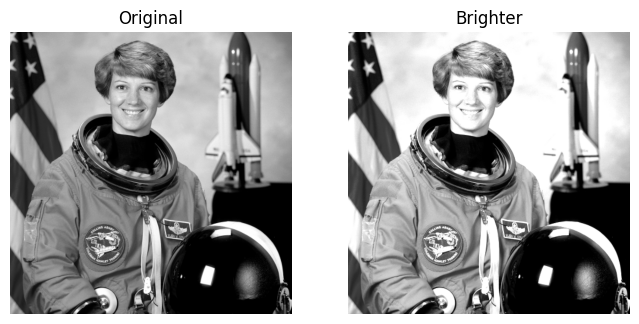

In [24]:
# Your code here
brighter = np.clip(gray.astype(int) + 60, 0, 255).astype(np.uint8)
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(gray, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(brighter, cmap="gray")
plt.title("Brighter")
plt.axis("off")

plt.show()

**Challenge B — Which digits does it get wrong?**
Find one test image the trained model **misclassifies**. Show it with the true label and the model's (wrong) prediction in the title.

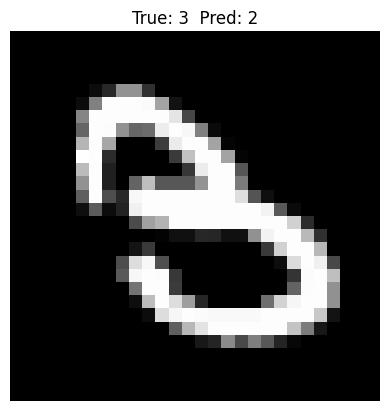

In [25]:
# Your code here
model.eval()

with torch.no_grad():
    for images, labels in test_loader:

        outputs = model(images)
        predicted = outputs.argmax(dim=1)

        for i in range(len(labels)):
            if predicted[i] != labels[i]:

                plt.imshow(images[i].squeeze(), cmap="gray")
                plt.title(f"True: {labels[i]}  Pred: {predicted[i]}")
                plt.axis("off")
                plt.show()
                break
        else:
            continue
        break

**Challenge C — More filters.**
Change `conv1` to use **16** filters instead of 8 (remember conv2's input must match), retrain for 2 epochs, and see if test accuracy improves.

In [26]:
# Your code here
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc1 = nn.Linear(32*7*7, 64)
        self.fc2 = nn.Linear(64,10)
    def forward(self,x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x,1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x